# Part 1


In [12]:
import json
import os
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from train import build_modular_dataset

In [13]:
ROOT = Path.cwd()
PART1_DIR = ROOT / "out" / "submission" / "part1"
PLOTS_DIR = PART1_DIR / "plots"
TABLES_DIR = PART1_DIR / "tables"

PART1_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("root:", ROOT)
print("part1:", PART1_DIR)

root: /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1
part1: /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1


In [ ]:
FAST_DEBUG = False

WARMUP_STEPS = 1500 if FAST_DEBUG else 100000
GROKKING_STEPS = 5000 if FAST_DEBUG else 500000
ABLATION_STEPS = 5000 if FAST_DEBUG else GROKKING_STEPS

EVAL_INTERVAL = 100 if FAST_DEBUG else 500
LOG_INTERVAL = 100 if FAST_DEBUG else 500
GROKKING_EVAL_INTERVAL = 200 if FAST_DEBUG else 2000
GROKKING_LOG_INTERVAL = 200 if FAST_DEBUG else 2000

BASE_OPTIMIZER = "adam"

WARMUP_WEIGHT_DECAY = 0.01
WARMUP_LR = 1e-3
WARMUP_MIN_LR = 1e-4
WARMUP_LR_SCHEDULE = "cosine"
WARMUP_WARMUP_STEPS = 1000 if not FAST_DEBUG else 50
WARMUP_GRAD_CLIP = 1.0

GROKKING_WEIGHT_DECAY = 0.01
GROKKING_LR = 3e-3
GROKKING_MIN_LR = 1e-4
GROKKING_LR_SCHEDULE = "cosine"
GROKKING_WARMUP_STEPS = 1000 if not FAST_DEBUG else 50
GROKKING_GRAD_CLIP = 1.0

print("FAST_DEBUG:", FAST_DEBUG)
print("WARMUP_STEPS:", WARMUP_STEPS)
print("GROKKING_STEPS:", GROKKING_STEPS)
print("ABLATION_STEPS:", ABLATION_STEPS)
print("BASE_OPTIMIZER:", BASE_OPTIMIZER)
print("WARMUP_LR_SCHEDULE:", WARMUP_LR_SCHEDULE)
print("GROKKING_LR:", GROKKING_LR)
print("GROKKING_EVAL_INTERVAL:", GROKKING_EVAL_INTERVAL)

FAST_DEBUG: False
WARMUP_STEPS: 100000
GROKKING_STEPS: 500000
ABLATION_STEPS: 500000
BASE_OPTIMIZER: adam
WARMUP_LR_SCHEDULE: cosine
GROKKING_LR: 0.003
GROKKING_EVAL_INTERVAL: 2000


In [15]:
def run(cmd: str):
    print(f"\n$ {cmd}")
    result = subprocess.run(cmd, shell=True)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed with code {result.returncode}: {cmd}")


def load_history(run_dir: Path) -> pd.DataFrame:
    path = run_dir / "history.csv"
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def load_metrics(run_dir: Path) -> dict:
    path = run_dir / "metrics.json"
    if not path.exists():
        raise FileNotFoundError(path)
    with open(path, "r") as f:
        return json.load(f)


## 1.1 Data Generation

In [5]:
rows = []
sample_rows = []

for p in [97, 113]:
    for op in ["+", "-", "/"]:
        split_dir = PART1_DIR / "splits" / f"p{p}_{'div' if op=='/' else ('add' if op=='+' else 'sub')}"
        tokenizer, train_data, val_data, test_data = build_modular_dataset(
            p=p,
            op=op,
            train_frac=0.3,
            val_frac=0.1,
            seed=42,
            save_split_dir=str(split_dir),
        )

        total = len(train_data) + len(val_data) + len(test_data)
        expected = p * (p - 1) if op == "/" else p * p

        rows.append(
            {
                "p": p,
                "op": op,
                "train": len(train_data),
                "val": len(val_data),
                "test": len(test_data),
                "total": total,
                "expected_total": expected,
                "matches_expected": total == expected,
            }
        )

        for split_name, split_data in [("train", train_data), ("val", val_data), ("test", test_data)]:
            s = split_data[0]
            full_ids = [s["x"][0]] + s["y"]
            sample_rows.append(
                {
                    "p": p,
                    "op": op,
                    "split": split_name,
                    "tokens": tokenizer.decode_ids(full_ids),
                    "target_pos": s["target_pos"],
                    "loss_mask": s["loss_mask"],
                }
            )

counts_df = pd.DataFrame(rows).sort_values(["p", "op"]).reset_index(drop=True)
samples_df = pd.DataFrame(sample_rows)

counts_df.to_csv(TABLES_DIR / "1_1_split_counts.csv", index=False)
samples_df.to_json(TABLES_DIR / "1_1_samples.json", orient="records", indent=2)

counts_df

,p,op,train,val,test,total,expected_total,matches_expected
0,97,+,2822,940,5647,9409,9409,True
1,97,-,2822,940,5647,9409,9409,True
2,97,/,2793,931,5588,9312,9312,True
3,113,+,3830,1276,7663,12769,12769,True
4,113,-,3830,1276,7663,12769,12769,True
5,113,/,3796,1265,7595,12656,12656,True


In [6]:
samples_df.head(18)

,p,op,split,tokens,target_pos,loss_mask
0,97,+,train,"[<BOS>, 73, +, 93, =, 69, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
1,97,+,val,"[<BOS>, 10, +, 14, =, 24, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
2,97,+,test,"[<BOS>, 16, +, 2, =, 18, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
3,97,-,train,"[<BOS>, 73, -, 93, =, 77, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
4,97,-,val,"[<BOS>, 10, -, 14, =, 93, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
5,97,-,test,"[<BOS>, 16, -, 2, =, 14, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
6,97,/,train,"[<BOS>, 24, /, 60, =, 78, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
7,97,/,val,"[<BOS>, 13, /, 2, =, 55, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
8,97,/,test,"[<BOS>, 77, /, 13, =, 88, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
9,113,+,train,"[<BOS>, 71, +, 4, =, 75, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"


### 1.1 Write-Up

We generated modular equation datasets in the form `<BOS> a op b = c <EOS>` for `op in {+, -, /}` and `p in {97, 113}`.
For division, we excluded `b=0`, so division has fewer examples than addition/subtraction.

Key dataset sizes (train/val/test):
- `p=97, +`: `2822 / 940 / 5647` (total `9409 = 97*97`)
- `p=97, -`: `2822 / 940 / 5647` (total `9409 = 97*97`)
- `p=97, /`: `2793 / 931 / 5588` (total `9312 = 97*96`)
- `p=113, +`: `3830 / 1276 / 7663` (total `12769 = 113*113`)
- `p=113, -`: `3830 / 1276 / 7663` (total `12769 = 113*113`)
- `p=113, /`: `3796 / 1265 / 7595` (total `12656 = 113*112`)

All totals match expected counts (see `tables/1_1_split_counts.csv`), so data generation and split construction are correct.


## 1.2 Warmup - Addition/Subtraction Experiments

In [7]:
import json
import shlex
import sys

SKIP_EXISTING_RUNS = True

def _latest_logged_step(run_dir: Path):
    history_path = run_dir / "history.json"

    if not history_path.exists():
        return None
    try:
        hist = json.loads(history_path.read_text())
    except Exception:
        return None
    if not hist:
        return None

    return hist[-1].get("step")

def _is_completed_run(run_dir: Path, target_steps: int):
    latest = _latest_logged_step(run_dir)
    ckpt_exists = (run_dir / "model_last.pt").exists() or (run_dir / "model.pt").exists()

    if isinstance(latest, int) and latest >= target_steps and ckpt_exists:
        return True

    return False

def run_train(run_dir: Path, op: str, p: int, n_layer: int, seed: int, steps: int,
    weight_decay: float = WARMUP_WEIGHT_DECAY,
    optimizer: str = BASE_OPTIMIZER, lr: float = WARMUP_LR, min_lr: float = WARMUP_MIN_LR,
    lr_schedule: str = WARMUP_LR_SCHEDULE, warmup_steps: int = WARMUP_WARMUP_STEPS,
    grad_clip: float = WARMUP_GRAD_CLIP, skip_existing: bool = SKIP_EXISTING_RUNS,
):
    if skip_existing and _is_completed_run(run_dir, steps):
        print(f"[skip] already complete: {run_dir}")
        return False

    out_dir_q = shlex.quote(str(run_dir))
    op_q = shlex.quote(op)

    cmd = (
        f"{shlex.quote(sys.executable)} train.py "
        f"--mode modular --op {op_q} --p {p} "
        f"--n_layer {n_layer} --n_head 4 --n_embd 128 "
        f"--steps {steps} --seed {seed} "
        f"--batch_size 128 --lr {lr} --min_lr {min_lr} --lr_schedule {lr_schedule} "
        f"--warmup_steps {warmup_steps} --grad_clip {grad_clip} "
        f"--beta1 0.9 --beta2 0.95 --weight_decay {weight_decay} --optimizer {optimizer} "
        f"--eval_interval {EVAL_INTERVAL} --log_interval {LOG_INTERVAL} "
        f"--out_dir {out_dir_q} --bias --resume"
    )
    run(cmd)
    return True


warmup_runs = []
executed_warmup = 0
for op in ["+", "-"]:
    op_name = "add" if op == "+" else "sub"
    for p in [97, 113]:
        for n_layer in [1, 2]:
            run_dir = PART1_DIR / "warmup" / f"{op_name}_p{p}_l{n_layer}_s42"
            warmup_runs.append({
                "name": run_dir.name,
                "run_dir": run_dir,
                "op": op,
                "p": p,
                "n_layer": n_layer,
                "seed": 42,
            })
            executed_warmup += int(run_train(
                run_dir=run_dir,
                op=op,
                p=p,
                n_layer=n_layer,
                seed=42,
                steps=WARMUP_STEPS,
                weight_decay=WARMUP_WEIGHT_DECAY,
                optimizer=BASE_OPTIMIZER,
                lr=WARMUP_LR,
                min_lr=WARMUP_MIN_LR,
                lr_schedule=WARMUP_LR_SCHEDULE,
                warmup_steps=WARMUP_WARMUP_STEPS,
                grad_clip=WARMUP_GRAD_CLIP,
            ))

# Required 3 random restarts for (+, p=97, 1-layer)
restart_runs = []
executed_restarts = 0
for seed in [101, 202, 303]:
    run_dir = PART1_DIR / "warmup_restarts" / f"add_p97_l1_s{seed}"
    restart_runs.append({
        "name": run_dir.name,
        "run_dir": run_dir,
        "op": "+",
        "p": 97,
        "n_layer": 1,
        "seed": seed,
    })
    executed_restarts += int(run_train(
        run_dir=run_dir,
        op="+",
        p=97,
        n_layer=1,
        seed=seed,
        steps=WARMUP_STEPS,
        weight_decay=WARMUP_WEIGHT_DECAY,
        optimizer=BASE_OPTIMIZER,
        lr=WARMUP_LR,
        min_lr=WARMUP_MIN_LR,
        lr_schedule=WARMUP_LR_SCHEDULE,
        warmup_steps=WARMUP_WARMUP_STEPS,
        grad_clip=WARMUP_GRAD_CLIP,
    ))

print("warmup runs configured:", len(warmup_runs), "executed now:", executed_warmup)
print("restart runs configured:", len(restart_runs), "executed now:", executed_restarts)


$ /opt/homebrew/Caskroom/miniconda/base/envs/cse493/bin/python train.py --mode modular --op + --p 97 --n_layer 1 --n_head 4 --n_embd 128 --steps 100000 --seed 42 --batch_size 128 --lr 0.001 --min_lr 0.0001 --lr_schedule cosine --warmup_steps 1000 --grad_clip 1.0 --beta1 0.9 --beta2 0.95 --weight_decay 0.01 --optimizer adam --eval_interval 500 --log_interval 500 --out_dir '/Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/warmup/add_p97_l1_s42' --bias --resume
number of parameters: 0.21M
[resume] model_last.pt not found in /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/warmup/add_p97_l1_s42; starting fresh
device=mps train=2822 val=940 test=5647 batch_size=128
step=1 train_loss=4.680046 train_acc=0.0000 val_loss=4.690321 val_acc=0.0000 test_loss=4.690012 test_acc=0.0000
step=500 train_loss=4.291574 train_acc=0.0804 val_loss=4.851421 val_acc=0.0021 test_loss=4.842137 test_acc=0.0012
step=1000 train_loss=4.252802 train_acc=0.0840

In [8]:
summary_rows = []
for r in warmup_runs + restart_runs:
    m = load_metrics(r["run_dir"])
    summary_rows.append({
        "name": r["name"],
        "op": r["op"],
        "p": r["p"],
        "n_layer": r["n_layer"],
        "seed": r["seed"],
        "best_step": m.get("step"),
        "train_loss": m.get("train_loss"),
        "train_acc": m.get("train_acc"),
        "val_loss": m.get("val_loss"),
        "val_acc": m.get("val_acc"),
        "test_loss": m.get("test_loss"),
        "test_acc": m.get("test_acc"),
    })

warmup_summary_df = pd.DataFrame(summary_rows)
warmup_summary_df.to_csv(TABLES_DIR / "1_2_warmup_summary.csv", index=False)
warmup_summary_df


,name,op,p,n_layer,seed,best_step,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc
0,add_p97_l1_s42,+,97,1,42,99000,2.399661,0.323529,2.439905,0.252128,2.439464,0.258013
1,add_p97_l2_s42,+,97,2,42,99000,2.398784,0.339476,2.439876,0.260638,2.438467,0.266690
2,add_p113_l1_s42,+,113,1,42,95500,2.595969,0.269974,2.631002,0.219436,2.625715,0.217147
3,add_p113_l2_s42,+,113,2,42,95500,2.599874,0.287206,2.636299,0.227273,2.629678,0.237244
4,sub_p97_l1_s42,-,97,1,42,97500,2.996353,0.206237,3.033172,0.160638,3.044043,0.140960
5,sub_p97_l2_s42,-,97,2,42,95500,2.881246,0.217931,2.916527,0.165957,2.920241,0.150699
6,sub_p113_l1_s42,-,113,1,42,97500,2.688002,0.298433,2.727227,0.244514,2.717089,0.255775
7,sub_p113_l2_s42,-,113,2,42,8500,3.089000,0.158486,3.118533,0.148903,3.111466,0.129975
8,add_p97_l1_s101,+,97,1,101,99000,2.391924,0.318214,2.433253,0.259574,2.439249,0.242784
9,add_p97_l1_s202,+,97,1,202,14500,2.486142,0.307229,2.610700,0.209574,2.627516,0.180804


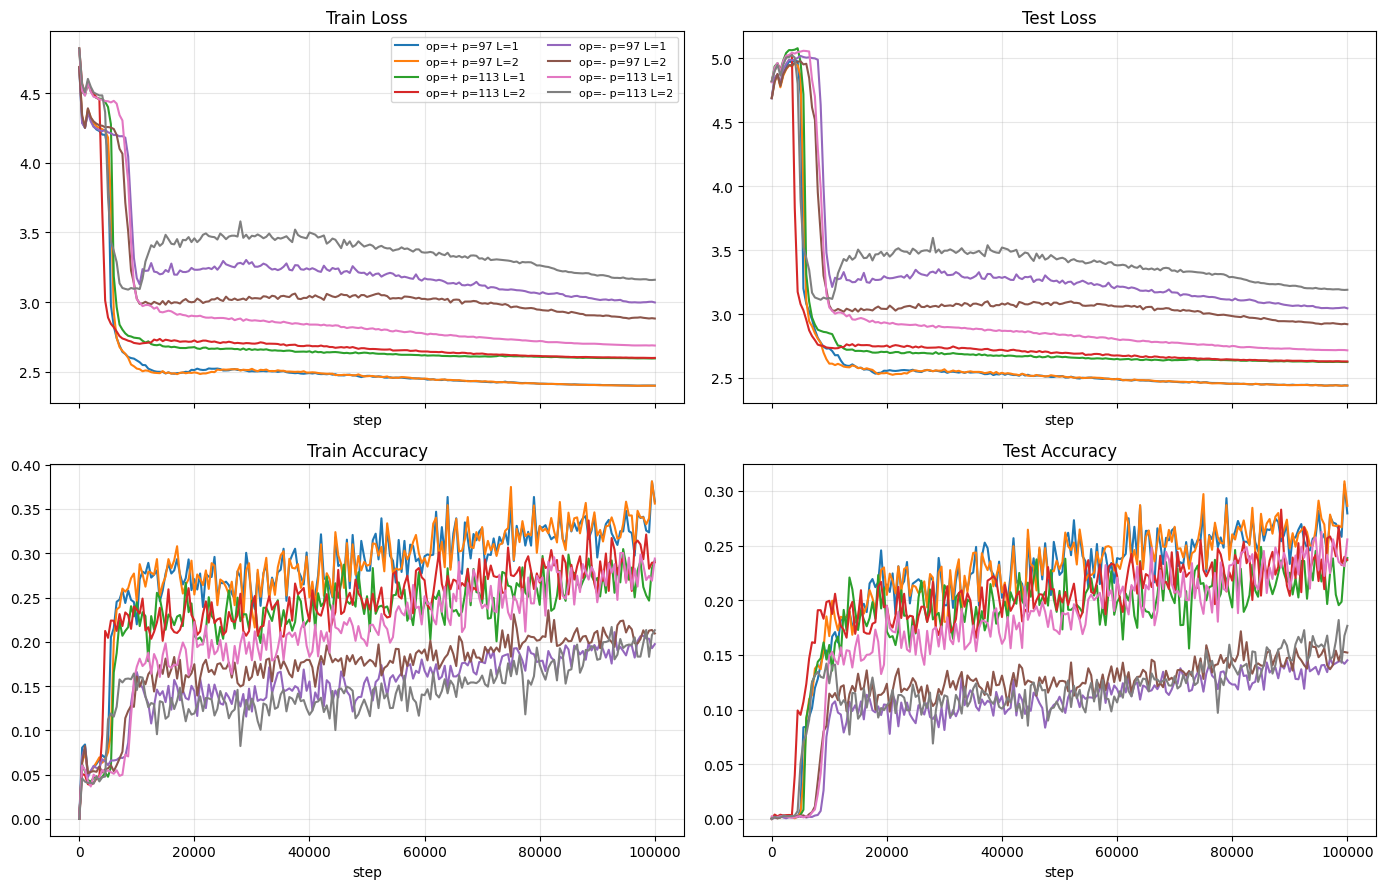

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for r in warmup_runs:
    h = load_history(r["run_dir"])
    label = f"op={r['op']} p={r['p']} L={r['n_layer']}"
    axes[0, 0].plot(h["step"], h["train_loss"], label=label)
    axes[0, 1].plot(h["step"], h["test_loss"], label=label)
    axes[1, 0].plot(h["step"], h["train_acc"], label=label)
    axes[1, 1].plot(h["step"], h["test_acc"], label=label)

axes[0, 0].set_title("Train Loss")
axes[0, 1].set_title("Test Loss")
axes[1, 0].set_title("Train Accuracy")
axes[1, 1].set_title("Test Accuracy")
for ax in axes.ravel():
    ax.set_xlabel("step")
    ax.grid(alpha=0.3)

axes[0, 0].legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "1_2_warmup_curves.png", dpi=180)
plt.show()


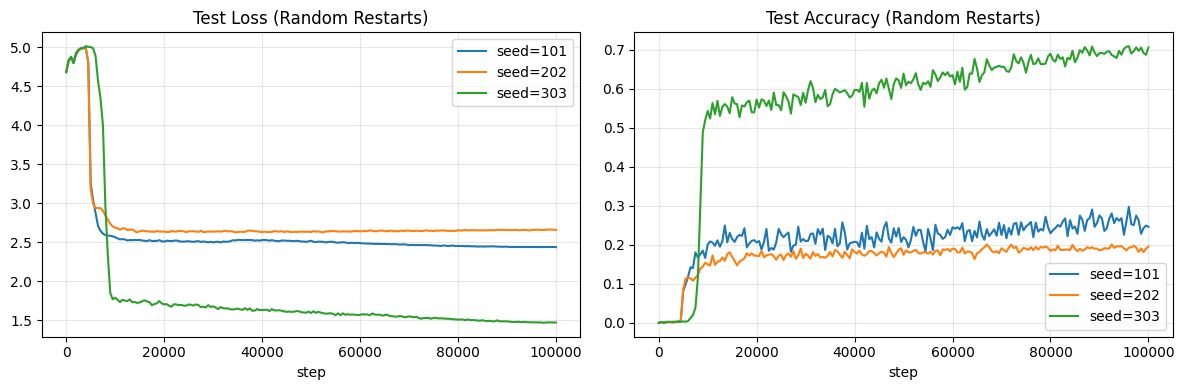

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for r in restart_runs:
    h = load_history(r["run_dir"])
    label = f"seed={r['seed']}"
    axes[0].plot(h["step"], h["test_loss"], label=label)
    axes[1].plot(h["step"], h["test_acc"], label=label)

axes[0].set_title("Test Loss (Random Restarts)")
axes[1].set_title("Test Accuracy (Random Restarts)")
for ax in axes:
    ax.set_xlabel("step")
    ax.grid(alpha=0.3)
    ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "1_2_random_restarts.png", dpi=180)
plt.show()


### 1.2 Write-Up

Setup used for warmup experiments:
- Model configs: 1-layer and 2-layer transformers, `n_embd=128`, `n_head=4`, FFN dimension `4*128=512`
- Tasks: modular addition and subtraction
- Moduli: `p=97` and `p=113`
- Optimizer: Adam, up to `100,000` steps with answer-token-only loss masking

Main observations:
- Addition generally outperformed subtraction for `p=97`:
  - `add_p97_l2_s42` test accuracy `0.2667` compared to `sub_p97_l2_s42` `0.1507`
- Increasing depth from 1 to 2 layers improved addition in both moduli:
  - `p=97`: `0.2580 -> 0.2667`
  - `p=113`: `0.2171 -> 0.2372`
- Subtraction was less stable across different settings:
  - `p=97`: `sub_p97_l1_s42=0.1410`, `sub_p97_l2_s42=0.1507`
  - `p=113`: `sub_p113_l1_s42=0.2558`, `sub_p113_l2_s42=0.1300`

Random restart `(op=+, p=97, 1-layer)` showed high variance:
- Seed 101: test accuracy `0.2428`
- Seed 202: test accuracy `0.1808`
- Seed 303: test accuracy `0.7057`

The seed choice can substantially affect generalization so in this case the variance is important to understand and get the same model architecture for training. 

## 1.3 Grokking

In [16]:
import json
import shlex
import sys

SKIP_EXISTING_GROKKING_RUNS = True

def _latest_logged_step(run_dir: Path):
    history_path = run_dir / "history.json"
    if not history_path.exists():
        return None
    try:
        hist = json.loads(history_path.read_text())
    except Exception:
        return None

    if not hist:
        return None

    return hist[-1].get("step")

def _is_completed_run(run_dir: Path, target_steps: int):
    latest = _latest_logged_step(run_dir)
    ckpt_exists = (run_dir / "model_last.pt").exists() or (run_dir / "model.pt").exists()

    if isinstance(latest, int) and latest >= target_steps and ckpt_exists:
        return True

    return False

baseline_div_dir = PART1_DIR / "grokking" / "baseline_div_p97"
if SKIP_EXISTING_GROKKING_RUNS and _is_completed_run(baseline_div_dir, GROKKING_STEPS):
    print(f"[skip] baseline already complete: {baseline_div_dir}")
else:
    cmd = (
        f"{shlex.quote(sys.executable)} train.py "
        "--mode modular --op / --p 97 "
        "--n_layer 2 --n_head 4 --n_embd 128 "
        f"--steps {GROKKING_STEPS} --seed 42 "
        f"--batch_size 128 --lr {GROKKING_LR} --min_lr {GROKKING_MIN_LR} "
        f"--lr_schedule {GROKKING_LR_SCHEDULE} --warmup_steps {GROKKING_WARMUP_STEPS} --grad_clip {GROKKING_GRAD_CLIP} "
        "--beta1 0.9 --beta2 0.95 "
        f"--weight_decay {GROKKING_WEIGHT_DECAY} --optimizer {BASE_OPTIMIZER} "
        f"--eval_interval {GROKKING_EVAL_INTERVAL} --log_interval {GROKKING_LOG_INTERVAL} "
        f"--out_dir {shlex.quote(str(baseline_div_dir))} --bias --resume"
    )
    run(cmd)


$ /opt/homebrew/Caskroom/miniconda/base/envs/cse493/bin/python train.py --mode modular --op / --p 97 --n_layer 2 --n_head 4 --n_embd 128 --steps 500000 --seed 42 --batch_size 128 --lr 0.003 --min_lr 0.0001 --lr_schedule cosine --warmup_steps 1000 --grad_clip 1.0 --beta1 0.9 --beta2 0.95 --weight_decay 0.01 --optimizer adam --eval_interval 2000 --log_interval 2000 --out_dir '/Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/grokking/baseline_div_p97' --bias --resume
number of parameters: 0.41M
[resume] loaded model from /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/grokking/baseline_div_p97/model_last.pt
[resume] loaded optimizer from /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/grokking/baseline_div_p97/optimizer_last.pt
[resume] history found with last step=500
device=mps train=2793 val=931 test=5588 batch_size=128
step=2000 train_loss=2.783151 train_acc=0.1722 val_loss=2.855428 val_acc=0.122

,run,train_acc_99_step,val_acc_99_step,test_acc_99_step,val_delay_after_train_99,test_delay_after_train_99
0,baseline_div_p97,None,None,None,None,None


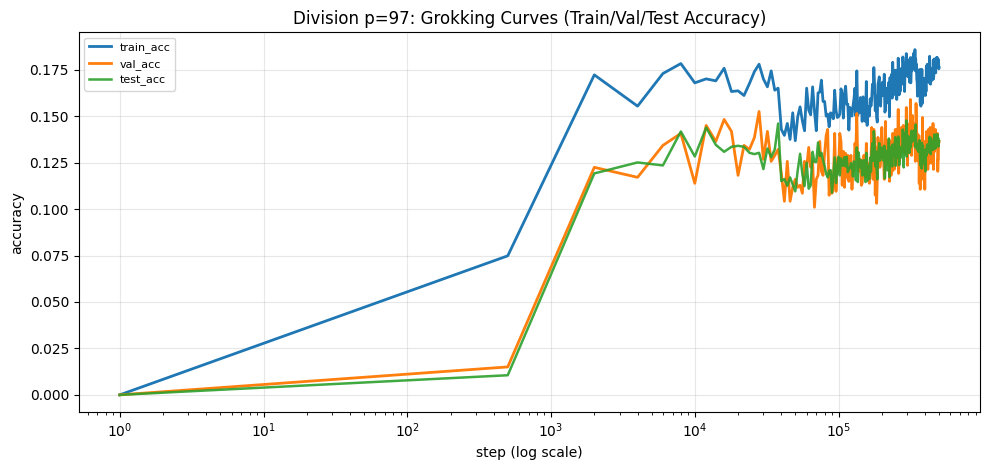

In [17]:
h = load_history(baseline_div_dir)

def first_step_at_or_above(df: pd.DataFrame, col: str, threshold: float):
    s = df.loc[df[col] >= threshold, "step"]
    return int(s.iloc[0]) if not s.empty else None

train_99_step = first_step_at_or_above(h, "train_acc", 0.99)
val_99_step = first_step_at_or_above(h, "val_acc", 0.99)
test_99_step = first_step_at_or_above(h, "test_acc", 0.99)

if train_99_step is None or val_99_step is None:
    val_delay_after_train_99 = None
else:
    val_delay_after_train_99 = val_99_step - train_99_step

if train_99_step is None or test_99_step is None:
    test_delay_after_train_99 = None
else:
    test_delay_after_train_99 = test_99_step - train_99_step

grokking_summary = pd.DataFrame([
    {
        "run": "baseline_div_p97",
        "train_acc_99_step": train_99_step,
        "val_acc_99_step": val_99_step,
        "test_acc_99_step": test_99_step,
        "val_delay_after_train_99": val_delay_after_train_99,
        "test_delay_after_train_99": test_delay_after_train_99,
    }
])
grokking_summary.to_csv(TABLES_DIR / "1_3_grokking_summary.csv", index=False)
display(grokking_summary)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(h["step"], h["train_acc"], label="train_acc", linewidth=2.0)
ax.plot(h["step"], h["val_acc"], label="val_acc", linewidth=2.0)
ax.plot(h["step"], h["test_acc"], label="test_acc", linewidth=1.8, alpha=0.9)

if train_99_step is not None:
    ax.axvline(train_99_step, linestyle="--", alpha=0.7, label="train acc>=99%")
if val_99_step is not None:
    ax.axvline(val_99_step, linestyle=":", alpha=0.7, label="val acc>=99%")
if test_99_step is not None:
    ax.axvline(test_99_step, linestyle="-.", alpha=0.7, label="test acc>=99%")

ax.set_xscale("log")
ax.set_xlabel("step (log scale)")
ax.set_ylabel("accuracy")
ax.set_title("Division p=97: Grokking Curves (Train/Val/Test Accuracy)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(PLOTS_DIR / "1_3_grokking_baseline.png", dpi=180)
plt.show()

### 1.3 Write-Up

Results for (Adam, `weight_decay=0.01`, `train_frac=0.3`, `500k` steps):
- No grokking transition was observed within `500,000` steps. Didn't do `1,000,000` steps due to time and compute restrictions. 
- `train_acc` never reached `1.0` so train->test grokking delay is undefined.
- Best test accuracy was `0.1476` at step `296,000`
- Best validation accuracy was `0.1590` at step `316,000`
- Final metrics at step `500,000`: `train_acc=0.1762`, `val_acc=0.1364`, `test_acc=0.1365`

These results show us that under this exact baseline optimzer/regularization setting, the model remains in a low accuracy regime and doesn't show any delayed generalization behavior in this budget. 

## 1.4 Ablations Analysis

Ablation A (paper-style optimizer):
- switch to `AdamW`
- set `weight_decay=1.0`
- keep train split at baseline (`train_frac=0.3`, `val_frac=0.1`)

Ablation B (data-size with paper optimizer):
- keep `AdamW` + `weight_decay=1.0`
- increase training fraction (`train_frac=0.5`, `val_frac=0.1`)

In [18]:
import shlex
import sys

ABLATION_OPTIMIZER = "adamw"
ABLATION_WEIGHT_DECAY = 1.0

ablation_runs = [
    {
        "name": "abl_adamw_wd1_trainfrac0p3",
        "weight_decay": ABLATION_WEIGHT_DECAY,
        "optimizer": ABLATION_OPTIMIZER,
        "train_frac": 0.3,
        "val_frac": 0.1,
        "lr": GROKKING_LR,
        "min_lr": GROKKING_MIN_LR,
        "lr_schedule": GROKKING_LR_SCHEDULE,
        "warmup_steps": GROKKING_WARMUP_STEPS,
        "grad_clip": GROKKING_GRAD_CLIP,
    },
    {
        "name": "abl_adamw_wd1_trainfrac0p5",
        "weight_decay": ABLATION_WEIGHT_DECAY,
        "optimizer": ABLATION_OPTIMIZER,
        "train_frac": 0.5,
        "val_frac": 0.1,
        "lr": GROKKING_LR,
        "min_lr": GROKKING_MIN_LR,
        "lr_schedule": GROKKING_LR_SCHEDULE,
        "warmup_steps": GROKKING_WARMUP_STEPS,
        "grad_clip": GROKKING_GRAD_CLIP,
    },
]

executed_ablations = 0
for ab in ablation_runs:
    run_dir = PART1_DIR / "ablations" / ab["name"]
    if SKIP_EXISTING_GROKKING_RUNS and _is_completed_run(run_dir, ABLATION_STEPS):
        print(f"[skip] ablation already complete: {run_dir}")
        continue

    cmd = (
        f"{shlex.quote(sys.executable)} train.py "
        "--mode modular --op / --p 97 "
        "--n_layer 2 --n_head 4 --n_embd 128 "
        f"--steps {ABLATION_STEPS} --seed 42 "
        "--batch_size 128 "
        f"--lr {ab['lr']} --min_lr {ab['min_lr']} "
        f"--lr_schedule {ab['lr_schedule']} --warmup_steps {ab['warmup_steps']} --grad_clip {ab['grad_clip']} "
        "--beta1 0.9 --beta2 0.95 "
        f"--weight_decay {ab['weight_decay']} --optimizer {ab['optimizer']} "
        f"--train_frac {ab['train_frac']} --val_frac {ab['val_frac']} "
        f"--eval_interval {GROKKING_EVAL_INTERVAL} --log_interval {GROKKING_LOG_INTERVAL} "
        f"--out_dir {shlex.quote(str(run_dir))} --bias --resume"
    )
    run(cmd)
    executed_ablations += 1

print("ablation runs configured:", len(ablation_runs), "executed now:", executed_ablations)


$ /opt/homebrew/Caskroom/miniconda/base/envs/cse493/bin/python train.py --mode modular --op / --p 97 --n_layer 2 --n_head 4 --n_embd 128 --steps 500000 --seed 42 --batch_size 128 --lr 0.003 --min_lr 0.0001 --lr_schedule cosine --warmup_steps 1000 --grad_clip 1.0 --beta1 0.9 --beta2 0.95 --weight_decay 1.0 --optimizer adamw --train_frac 0.3 --val_frac 0.1 --eval_interval 2000 --log_interval 2000 --out_dir '/Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/ablations/abl_adamw_wd1_trainfrac0p3' --bias --resume
number of parameters: 0.41M
[resume] model_last.pt not found in /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/ablations/abl_adamw_wd1_trainfrac0p3; starting fresh
device=mps train=2793 val=931 test=5588 batch_size=128
step=1 train_loss=4.694038 train_acc=0.0000 val_loss=4.679460 val_acc=0.0000 test_loss=4.683803 test_acc=0.0000
step=2000 train_loss=0.444923 train_acc=0.8797 val_loss=0.486024 val_acc=0.8614 test_loss=0.4810

In [19]:
def first_step_at_or_above(df: pd.DataFrame, col: str, threshold: float):
    s = df.loc[df[col] >= threshold, "step"]
    return int(s.iloc[0]) if not s.empty else None

def grokking_delay(history_df: pd.DataFrame, train_thr: float, test_thr: float):
    train_step = first_step_at_or_above(history_df, "train_acc", train_thr)
    if train_step is None:
        return train_step, None, None

    after = history_df[history_df["step"] >= train_step]
    s = after.loc[after["test_acc"] >= test_thr, "step"]
    test_step = int(s.iloc[0]) if not s.empty else None
    delay = None if test_step is None else test_step - train_step
    return train_step, test_step, delay

rows = []
all_runs = [("baseline_div_p97", baseline_div_dir)] + [
    (ab["name"], PART1_DIR / "ablations" / ab["name"]) for ab in ablation_runs
]

for run_name, run_dir in all_runs:
    h = load_history(run_dir)

    train_1, test_1, delay_1 = grokking_delay(h, train_thr=1.0, test_thr=1.0)
    train_99, test_99, delay_99 = grokking_delay(h, train_thr=0.99, test_thr=0.99)

    rows.append(
        {
            "run": run_name,
            "train_acc_1_step": train_1,
            "test_acc_1_step": test_1,
            "grokking_delay_steps_strict": delay_1,
            "train_acc_99_step": train_99,
            "test_acc_99_step": test_99,
            "grokking_delay_steps_99": delay_99,
        }
    )

ablation_df = pd.DataFrame(rows)
ablation_df.to_csv(TABLES_DIR / "1_4_ablation_comparison.csv", index=False)
display(ablation_df)

,run,train_acc_1_step,test_acc_1_step,grokking_delay_steps_strict,train_acc_99_step,test_acc_99_step,grokking_delay_steps_99
0,baseline_div_p97,NaN,NaN,NaN,NaN,NaN,NaN
1,abl_adamw_wd1_trainfrac0p3,222000.0,270000.0,48000.0,58000.0,102000.0,44000.0
2,abl_adamw_wd1_trainfrac0p5,NaN,NaN,NaN,264000.0,264000.0,0.0


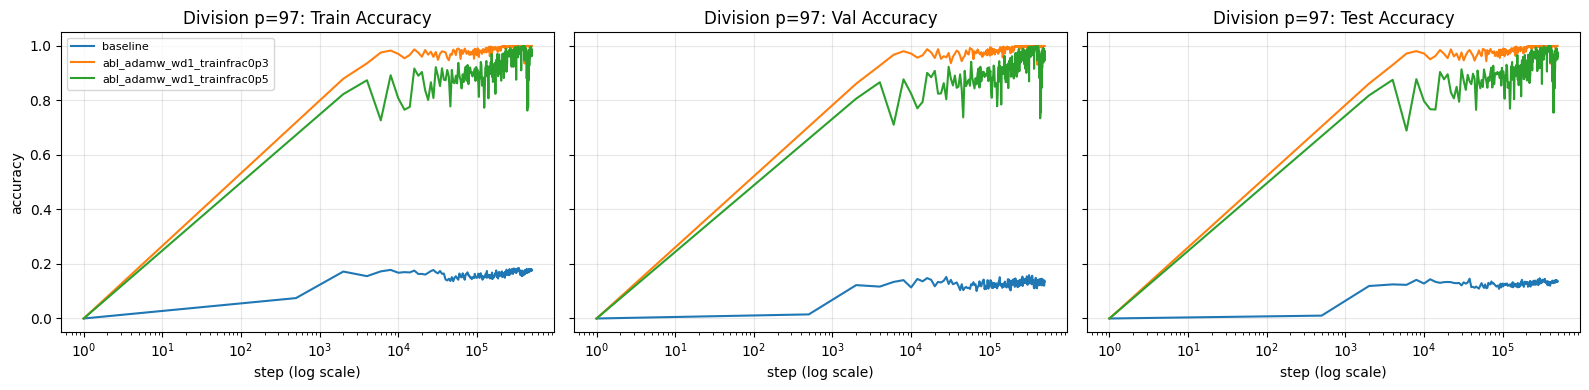

In [ ]:
# Overlay baseline + ablations on train/val/test accuracy
baseline_hist = load_history(baseline_div_dir)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True, sharey=True)

series = [
    ("train_acc", "Train Accuracy"),
    ("val_acc", "Val Accuracy"),
    ("test_acc", "Test Accuracy"),
]

all_runs = [("baseline", baseline_hist)]
for ab in ablation_runs:
    run_dir = PART1_DIR / "ablations" / ab["name"]
    all_runs.append((ab["name"], load_history(run_dir)))

for ax, (col, title) in zip(axes, series):
    for name, h in all_runs:
        ax.plot(h["step"], h[col], label=name)
    ax.set_title(f"Division p=97: {title}")
    ax.set_xscale("log")
    ax.set_xlabel("step (log scale)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("accuracy")
axes[0].legend(fontsize=8)

fig.tight_layout()
fig.savefig(PLOTS_DIR / "1_4_ablation_overlay.png", dpi=180)
plt.show()

### 1.4 Write-Up

We test paper style regularization/optimizer settings for faster and more reliable grokking.

Ablation A: `abl_adamw_wd1_trainfrac0p3` (`AdamW`, `weight_decay=1.0`, `train_frac=0.3`)
- Relaxed criterion (`>=0.99`):
  - `train_acc>=0.99` at step `58,000`
  - `test_acc>=0.99` at step `102,000`
  - delay = `44,000` steps
- Strict criterion (`=1.0`):
  - `train_acc=1.0` at step `222,000`
  - `test_acc=1.0` at step `270,000`
  - delay = `48,000` steps
- This shows grokking behavior

Ablation B: `abl_adamw_wd1_trainfrac0p5` (`AdamW`, `weight_decay=1.0`, `train_frac=0.5`)
- Relaxed criterion (`>=0.99`):
  - `train_acc>=0.99` and `test_acc>=0.99` both at step `264,000`
  - delay = `0` steps
- Strict criterion (`=1.0`) wasn't reached by `500,000` steps
- Peak test accuracy was quite high (`0.9997` at step `406,000`), but final test accuracy at step `500,000` dropped to `0.9621`

Conclusion:
- Compared to the baseline, `AdamW + weight_decay=1.0` dramatically improved generalization dynamics and showed signs of grokking. 
- `train_frac=0.3` produced the cleanest delayed generalization signature which is clear train first, test-later transition.
- `train_frac=0.5` achieved strong generalization too but with less clean strict-criterion convergence by the end of the run